<a href="https://colab.research.google.com/github/Valtern/PCVK_Ganjil_2025/blob/main/week10_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import google.colab.drive
google.colab.drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

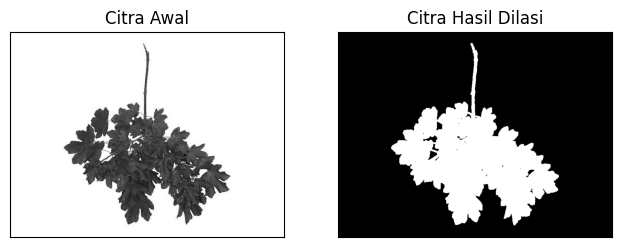

In [11]:
def dilasi_citra(F, w):
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    SED = np.ones((w, w), dtype=np.uint8)
    constant1 = (w - 1) // 2

    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD

img_d = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
ret, thresh = cv2.threshold(img_d, 125, 200, cv2.THRESH_BINARY_INV)
w = 5

imgD = dilasi_citra(thresh, w)

plt.figure(figsize=(12, 6))

plt.subplot(131)
plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])

plt.subplot(132)
plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi')
plt.xticks([]), plt.yticks([])
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[[1 1 1]
 [1 1 1]
 [1 1 1]]


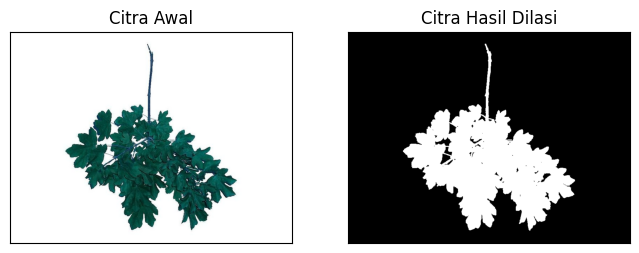

In [10]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

img = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, thresh = cv2.threshold(img_gray, 127, 225, cv2.THRESH_BINARY_INV)

kernel = np.ones((3,3), np.uint16)
dilasi = cv2.dilate(thresh, kernel, iterations = 1)

print(kernel)

plt.figure(figsize=(8, 4))
plt.subplot(121), plt.imshow(img), plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(dilasi, cmap='gray'), plt.title('Citra Hasil Dilasi')
plt.xticks([]), plt.yticks([])
plt.show()

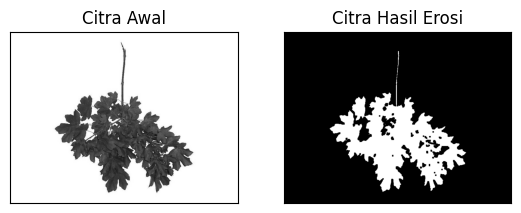

In [14]:
def erosi_citra(F, k):
    m, n = F.shape

    SE = np.ones((k, k), dtype=np.uint8)
    constant = (k - 1) // 2

    imgE = np.zeros((m, n), dtype=np.uint8)

    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE

img_e = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
ret1, thresh1 = cv2.threshold(img_e, 175, 225, cv2.THRESH_BINARY_INV)
k = 5

imgE = erosi_citra(thresh1, k)

plt.figure(figsize=(10, 5))
plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi'), plt.xticks([]), plt.yticks([])
plt.show()

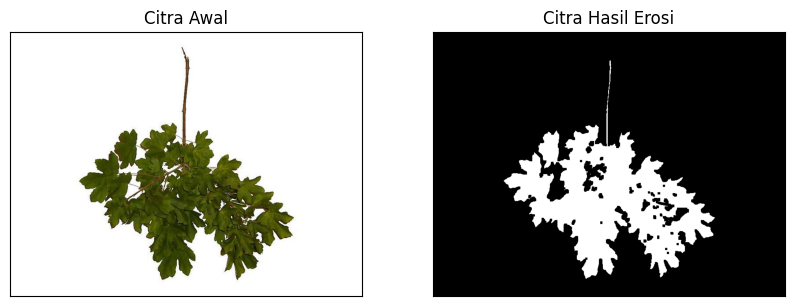

In [15]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, thresh_inv = cv2.threshold(img_gray, 175, 225, cv2.THRESH_BINARY_INV)

kernel = np.ones((5,5), np.uint8)
erosion = cv2.erode(thresh_inv, kernel, iterations = 1)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(erosion, cmap='gray'), plt.title('Citra Hasil Erosi')
plt.xticks([]), plt.yticks([])
plt.show()

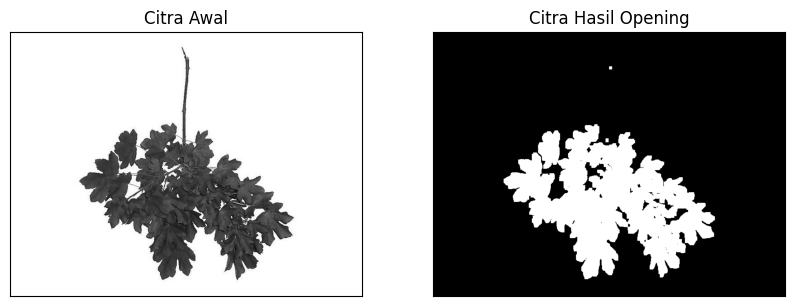

In [16]:
def dilasi_citra(F, w):
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)
    SED = np.ones((w, w), dtype=np.uint8)
    constant1 = (w - 1) // 2
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD

def erosi_citra(F, k):
    m, n = F.shape
    SE = np.ones((k, k), dtype=np.uint8)
    constant = (k - 1) // 2
    imgE = np.zeros((m, n), dtype=np.uint8)
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)
    return imgE

img_o = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
reto, thresho = cv2.threshold(img_o, 127, 225, cv2.THRESH_BINARY_INV)
k = 7

imgo = dilasi_citra(erosi_citra(thresho, k), k)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_o, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(imgo, cmap='gray')
plt.title('Citra Hasil Opening'), plt.xticks([]), plt.yticks([])
plt.show()

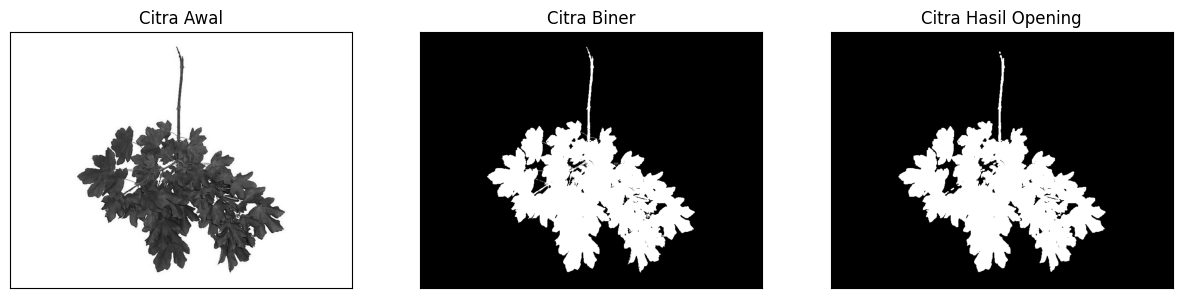

In [18]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY_INV)
kernel = np.ones((3,3), np.uint8)

openn = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(thresh, cmap='gray')
plt.title('Citra Biner'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(openn, cmap='gray')
plt.title('Citra Hasil Opening'), plt.xticks([]), plt.yticks([])
plt.show()

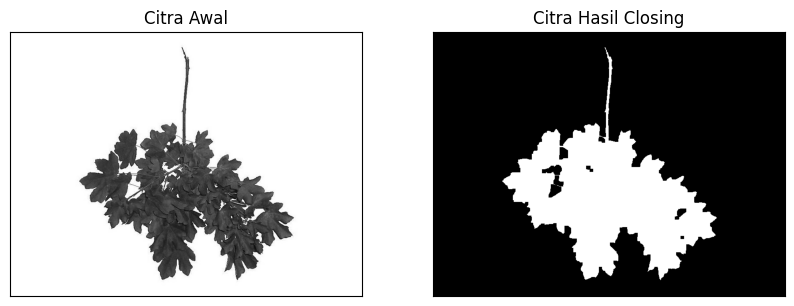

In [19]:
def dilasi_citra(F, w):
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)
    SED = np.ones((w, w), dtype=np.uint8)
    constant1 = (w - 1) // 2
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD

def erosi_citra(F, k):
    m, n = F.shape
    SE = np.ones((k, k), dtype=np.uint8)
    constant = (k - 1) // 2
    imgE = np.zeros((m, n), dtype=np.uint8)
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)
    return imgE

img_c = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
retc, threshc = cv2.threshold(img_c, 127, 225, cv2.THRESH_BINARY_INV)
k = 7

imgC = erosi_citra(dilasi_citra(threshc, k), k)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_c, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(imgC, cmap='gray')
plt.title('Citra Hasil Closing'), plt.xticks([]), plt.yticks([])
plt.show()

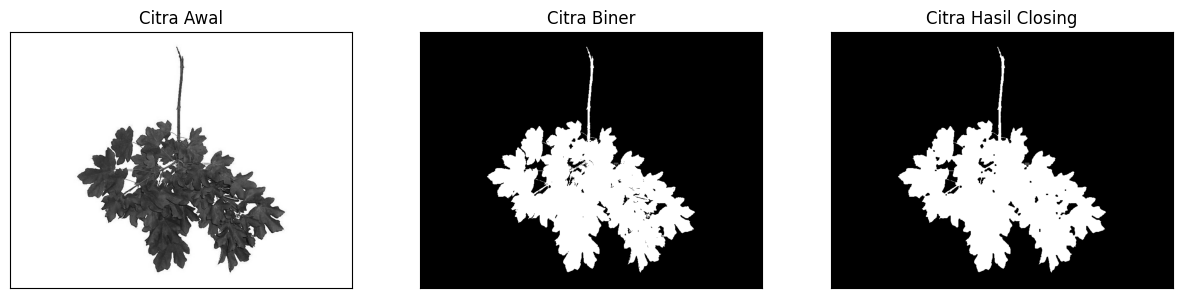

In [21]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY_INV)
kernel = np.ones((3,3), np.uint8)

closs = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(thresh, cmap='gray')
plt.title('Citra Biner'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(closs, cmap='gray')
plt.title('Citra Hasil Closing'), plt.xticks([]), plt.yticks([])
plt.show()

SED Cross 3


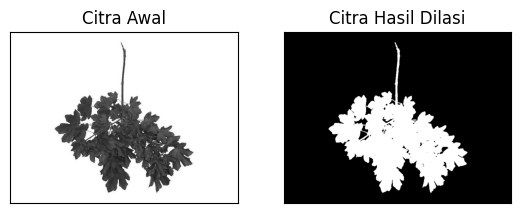

In [23]:
def dilasi_citra(F, w):
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    SED = np.array([[0, 1, 0],
                    [1, 1, 1],
                    [0, 1, 0]], dtype=np.uint8)

    constant1 = (w - 1) // 2

    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD

print('SED Cross 3')
img_d = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY_INV)
w = 3

imgD = dilasi_citra(thresh, w)

plt.figure(figsize=(10, 5))
plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi'), plt.xticks([]), plt.yticks([])
plt.show()

SED Cross 5


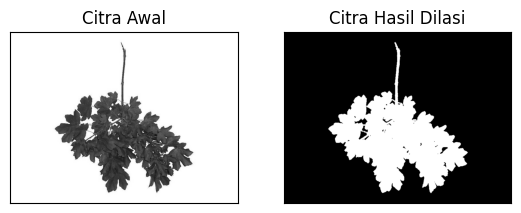

In [24]:
def dilasi_citra(F, w):
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    SED = np.array([[0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0],
                    [1, 1, 1, 1, 1],
                    [0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0]], dtype=np.uint8)

    constant1 = (w - 1) // 2

    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD

print('SED Cross 5')
img_d = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY_INV)
w = 5

imgD = dilasi_citra(thresh, w)

plt.figure(figsize=(10, 5))
plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi'), plt.xticks([]), plt.yticks([])
plt.show()

SED Circle 3


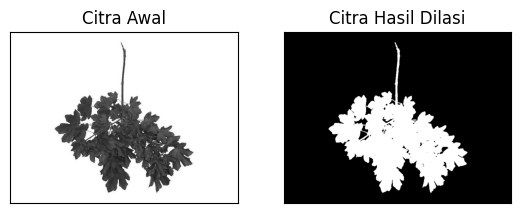

In [25]:
def dilasi_citra(F, w):
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    SED = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (w, w))

    constant1 = (w - 1) // 2

    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD

print('SED Circle 3')
img_d = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY_INV)
w = 3

imgD = dilasi_citra(thresh, w)

plt.figure(figsize=(10, 5))
plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi'), plt.xticks([]), plt.yticks([])
plt.show()

SED Circle 5


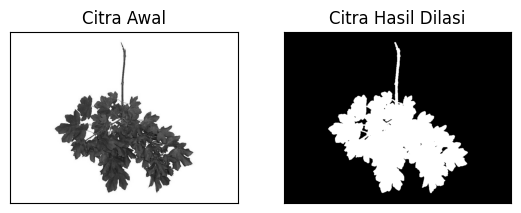

In [27]:
def dilasi_citra(F, w):
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    SED = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (w, w))

    constant1 = (w - 1) // 2

    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD

print('SED Circle 5')
img_d = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY_INV)
w = 5

imgD = dilasi_citra(thresh, w)

plt.figure(figsize=(10, 5))
plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi'), plt.xticks([]), plt.yticks([])
plt.show()

SE Rectangle 3x5


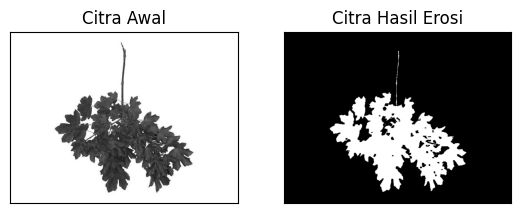

In [29]:
def erosi_citra(F, p, l):
    m, n = F.shape

    SE = cv2.getStructuringElement(cv2.MORPH_RECT, (p, l))

    constant1 = (l - 1) // 2
    constant2 = (p - 1) // 2

    imgE = np.zeros((m, n), dtype=np.uint8)

    for i in range(constant1, m - constant1):
        for j in range(constant2, n - constant2):
            temp = F[i - constant1:i + constant1 + 1, j - constant2:j + constant2 + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE

print('SE Rectangle 3x5')
img_e = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY_INV)
p = 5
l = 3

imgE = erosi_citra(thresh1, p, l)

plt.figure(figsize=(10, 5))
plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi'), plt.xticks([]), plt.yticks([])
plt.show()

SE Rectangle 5x7


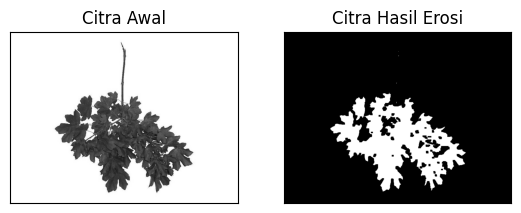

In [30]:
def erosi_citra(F, p, l):
    m, n = F.shape

    SE = cv2.getStructuringElement(cv2.MORPH_RECT, (p, l))

    constant1 = (l - 1) // 2
    constant2 = (p - 1) // 2

    imgE = np.zeros((m, n), dtype=np.uint8)

    for i in range(constant1, m - constant1):
        for j in range(constant2, n - constant2):
            temp = F[i - constant1:i + constant1 + 1, j - constant2:j + constant2 + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE

print('SE Rectangle 5x7')
img_e = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY_INV)
p = 7
l = 5

imgE = erosi_citra(thresh1, p, l)

plt.figure(figsize=(10, 5))
plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi'), plt.xticks([]), plt.yticks([])
plt.show()

SE Line Vertikal 3


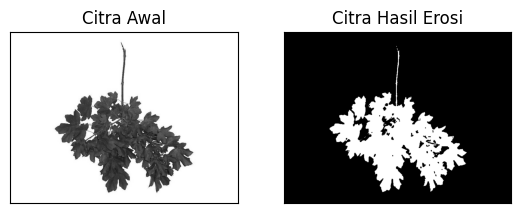

In [33]:
def erosi_citra(F, k):
    m, n = F.shape

    SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1, k))

    constant = (k - 1) // 2

    imgE = np.zeros((m, n), dtype=np.uint8)

    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE

print('SE Line Vertikal 3')
img_e = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY_INV)
k = 3

imgE = erosi_citra(thresh1, k)

plt.figure(figsize=(10, 5))
plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi'), plt.xticks([]), plt.yticks([])
plt.show()

SE Line Vertikal 5


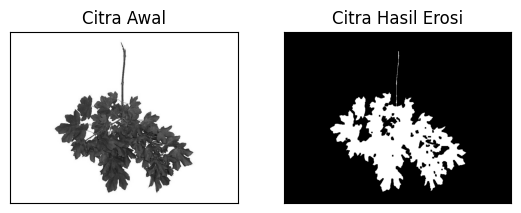

In [34]:
def erosi_citra(F, k):
    m, n = F.shape

    SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1, k))

    constant = (k - 1) // 2

    imgE = np.zeros((m, n), dtype=np.uint8)

    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE

print('SE Line Vertikal 5')
img_e = cv2.imread('/content/drive/MyDrive/PCVK/Image/leaves.jpg', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY_INV)
k = 5

imgE = erosi_citra(thresh1, k)

plt.figure(figsize=(10, 5))
plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi'), plt.xticks([]), plt.yticks([])
plt.show()

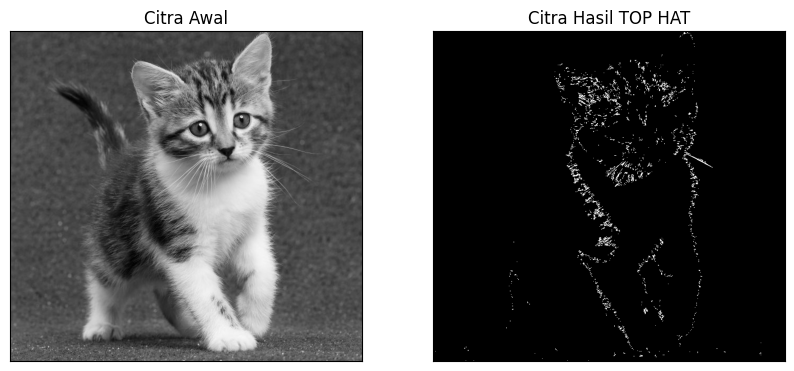

In [37]:
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

img = cv2.imread('/content/drive/MyDrive/PCVK/Image/kitten01.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh_inv = cv2.threshold(img_gray, 127, 225, cv2.THRESH_BINARY_INV)

tophat_img = cv2.morphologyEx(thresh_inv,
                            cv2.MORPH_TOPHAT,
                            kernel)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_gray, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(tophat_img, cmap='gray')
plt.title('Citra Hasil TOP HAT'), plt.xticks([]), plt.yticks([])
plt.show()

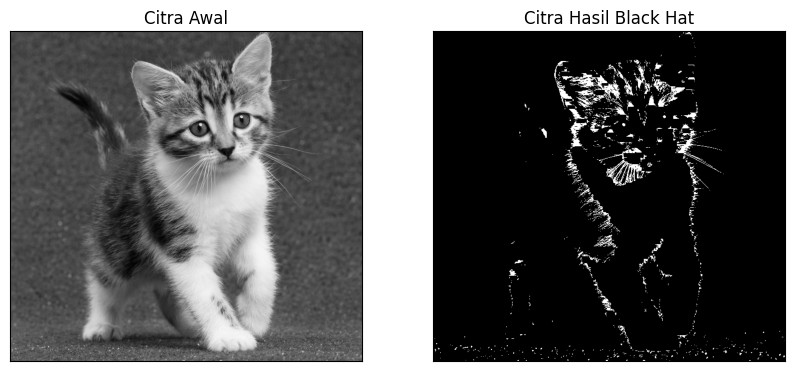

In [38]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Image/kitten01.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh_inv = cv2.threshold(img_gray, 127, 225, cv2.THRESH_BINARY_INV)

Kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
blackhat = cv2.morphologyEx(thresh_inv, cv2.MORPH_BLACKHAT, Kernel)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_gray, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(blackhat, cmap='gray')
plt.title('Citra Hasil Black Hat'), plt.xticks([]), plt.yticks([])
plt.show()

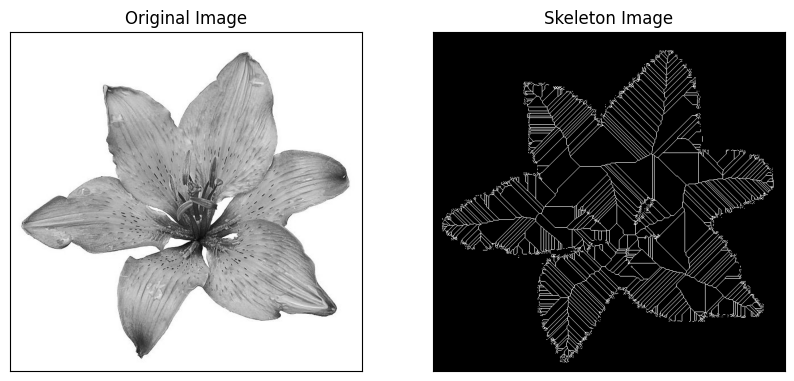

In [41]:
from skimage import filters
from skimage.morphology import skeletonize

img = cv2.imread('/content/drive/MyDrive/PCVK/Image/lily.jpg', 0)

binary = img < filters.threshold_triangle(img)

binary_cp = binary.copy()
binary_cp[binary_cp == True] = 1
binary_cp[binary_cp == False] = 0

skeleton = skeletonize(binary_cp)

plt.figure(figsize=(10, 10))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(skeleton, cmap='gray')
plt.title('Skeleton Image'), plt.xticks([]), plt.yticks([])
plt.show()

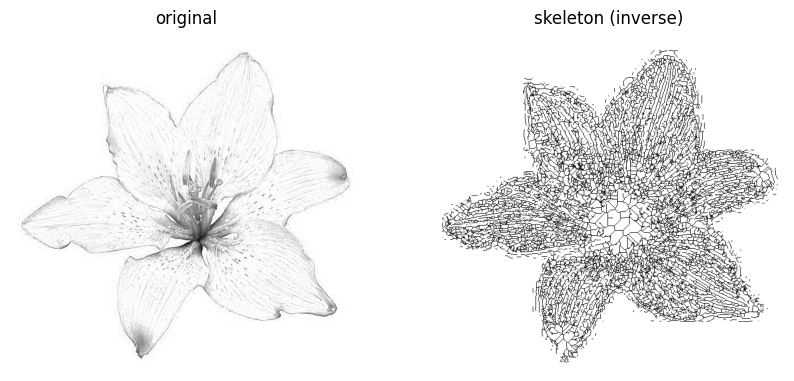

In [43]:
from skimage import io


img = io.imread('/content/drive/MyDrive/PCVK/Image/lily.jpg')[..., 0]

binary = img < filters.threshold_triangle(img)

skeleton = skeletonize(binary)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('original')
ax[0].set_axis_off()

ax[1].imshow(skeleton, cmap='gray_r')
ax[1].set_title('skeleton (inverse)')
ax[1].set_axis_off()

plt.show()

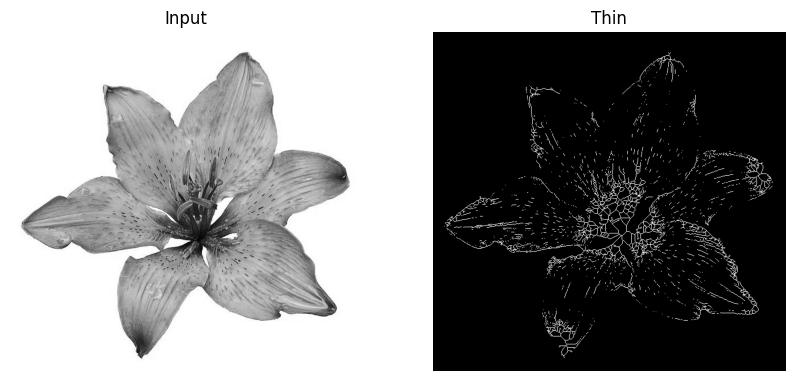

In [44]:
from skimage import img_as_float
from skimage import io, color, morphology

image = img_as_float(color.rgb2gray(io.imread('/content/drive/MyDrive/PCVK/Image/lily.jpg')))
image_binary = image < 0.5

out_thin = morphology.thin(image_binary)

f, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))

ax0.imshow(image, cmap='gray')
ax0.set_title('Input')
ax0.set_axis_off()

ax1.imshow(out_thin, cmap='gray')
ax1.set_title('Thin')
ax1.set_axis_off()

plt.show()